# Problem
- predict whether a movie is Flop, Average, or Hit based on its features.

In [84]:
## Imports
import pandas as pd
import numpy as np

import sys
from pathlib import Path
PROJECT_ROOT= Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
from src.preprocessing import load_data, build_preprocessor, split_data,extract_cat_col_num_cols

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import  precision_score, recall_score, f1_score





In [85]:
## Load data
df=load_data()
df.head()

,color,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,genres,num_voted_users,cast_total_facebook_likes,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,723.0,178.0,0.0,855.0,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,886204,4834,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,302.0,169.0,563.0,1000.0,40000.0,309404152.0,Action|Adventure|Fantasy,471220,48350,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,602.0,148.0,0.0,161.0,11000.0,200074175.0,Action|Adventure|Thriller,275868,11700,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,Action|Thriller,1144337,106759,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,NaN,NaN,131.0,NaN,131.0,NaN,Documentary,8,143,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [86]:
df=df.copy()

In [87]:
## Meta data
print("No.of rows:",df.shape[0])
print("\n No.of columns:",df.shape[1])
print("\n All columns:",df.columns.to_list())
print ("\n Data-types:",df.dtypes)
print("\n Info:")
df.info()
print ("\n no.of Duplicates:",df.duplicated().sum())

No.of rows: 5043

 No.of columns: 21

 All columns: ['color', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'genres', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

 Data-types: color                         object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_1_facebook_likes       float64
gross                        float64
genres                        object
num_voted_users                int64
cast_total_facebook_likes      int64
facenumber_in_poster         float64
num_user_for_reviews         float64
language                      object
country                       object
content_rating               

In [88]:
## remove duplicates
df.drop_duplicates(inplace = True)
print("Count of Duplicates:",df.duplicated().sum())

Count of Duplicates: 0


In [89]:
## Null values
df.isnull().sum()

color                         19
num_critic_for_reviews        49
duration                      15
director_facebook_likes      103
actor_3_facebook_likes        23
actor_1_facebook_likes         7
gross                        874
genres                         0
num_voted_users                0
cast_total_facebook_likes      0
facenumber_in_poster          13
num_user_for_reviews          21
language                      14
country                        5
content_rating               301
budget                       487
title_year                   107
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 327
movie_facebook_likes           0
dtype: int64

In [90]:
def classify_movie(score):
    if score <= 4:
        return "Flop"
    elif score <= 7:
        return "Average"
    else:
        return "Hit"

df["Classify"] = df["imdb_score"].apply(classify_movie)

In [91]:
df['Classify'].isnull().sum()

np.int64(0)

In [92]:
# Seperate feature and target
X =df.drop(["Classify","imdb_score"],axis=1)     # features
y =df["Classify"]                     # target

In [93]:
# split data
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
print(df['Classify'].value_counts())

Classify
Average    3249
Hit        1577
Flop        172
Name: count, dtype: int64


# Logistic regression

In [95]:
preprocessor = build_preprocessor(X_train)

model_lr = LogisticRegression(max_iter=1000,class_weight="balanced")

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_lr)
])

In [96]:
# Training
pipe_lr.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                   'director_facebook_likes',
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [97]:
print(y_train.head())
print(y_train.dtype)
print(y_train.unique()[:20])

1750    Average
4017        Hit
2938    Average
1607    Average
3238    Average
Name: Classify, dtype: object
object
['Average' 'Hit' 'Flop']


In [98]:
print(y_train.value_counts())

Classify
Average    2625
Hit        1232
Flop        141
Name: count, dtype: int64


In [99]:
# prediction

y_pred_lr = pipe_lr.predict(X_test)
df_pred_lr = pd.DataFrame({"Actual":y_test, "Prediction":y_pred_lr})
df_pred_lr.head(10)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Hit
5031,Average,Hit
4968,Flop,Average
4759,Hit,Average
158,Hit,Hit
713,Average,Average
4700,Average,Average
1190,Average,Hit


In [100]:
### model evaluation
accuracy_lr = accuracy_score(y_test,y_pred_lr)
conf_lr = confusion_matrix(y_test,y_pred_lr)
report_lr= classification_report(y_test,y_pred_lr)


print(f"Model Accuracy of Logistic Regression:{accuracy_lr*100:.2f}%")
print ("\n Classification Report for Logistic Regression: \n",report_lr)
print ("\n Confusion matrix:\n for Logistic Regression",conf_lr)

Model Accuracy of Logistic Regression:66.80%

 Classification Report for Logistic Regression: 
               precision    recall  f1-score   support

     Average       0.80      0.67      0.73       624
        Flop       0.12      0.52      0.19        31
         Hit       0.69      0.69      0.69       345

    accuracy                           0.67      1000
   macro avg       0.54      0.62      0.53      1000
weighted avg       0.74      0.67      0.70      1000


 Confusion matrix:
 for Logistic Regression [[415 103 106]
 [ 15  16   0]
 [ 90  18 237]]


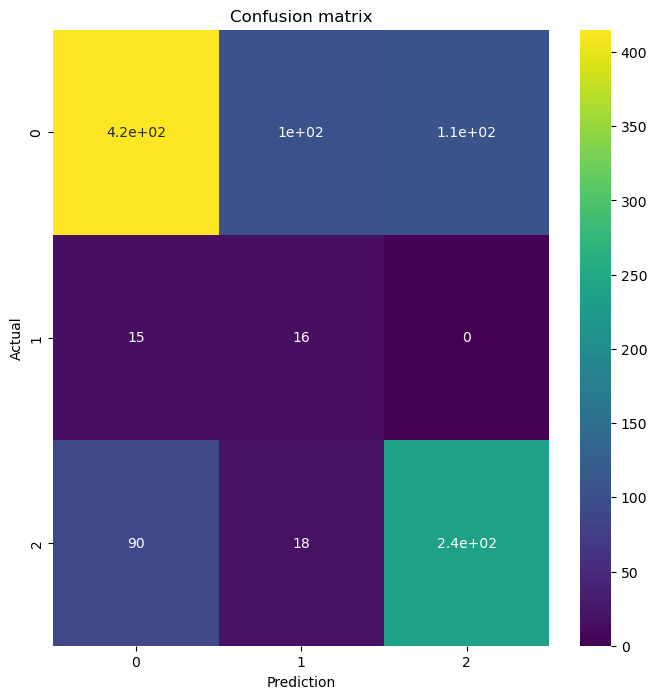

In [101]:
## Visualize a confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(conf_lr,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

# Decision Tree

In [102]:
preprocessor = build_preprocessor(X_train)

model_dt = DecisionTreeClassifier(class_weight="balanced")

pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_dt)
])

In [103]:
# Training
pipe_dt.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                   'director_facebook_likes',
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier(class_weight='balanced'))])

In [104]:
# prediction

y_pred_dt = pipe_dt.predict(X_test)
df_pred_dt = pd.DataFrame({"Actual":y_test, "Prediction":y_pred_dt})
df_pred_dt.head(10)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Hit
5031,Average,Flop
4968,Flop,Average
4759,Hit,Average
158,Hit,Average
713,Average,Average
4700,Average,Average
1190,Average,Average


In [105]:
### model evaluation
accuracy_dt = accuracy_score(y_test,y_pred_dt)
conf_dt = confusion_matrix(y_test,y_pred_dt)
report_dt= classification_report(y_test,y_pred_dt)


print(f"Model Accuracy for Decision Tree:{accuracy_dt*100:.2f}%")
print ("\n Classification Report for Decision Tree: \n",report_dt)
print ("\n Confusion matrix for Decision Tree:\n",conf_dt)

Model Accuracy for Decision Tree:70.50%

 Classification Report for Decision Tree: 
               precision    recall  f1-score   support

     Average       0.76      0.79      0.78       624
        Flop       0.07      0.10      0.08        31
         Hit       0.68      0.60      0.64       345

    accuracy                           0.70      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.71      0.70      0.71      1000


 Confusion matrix for Decision Tree:
 [[496  35  93]
 [ 24   3   4]
 [136   3 206]]


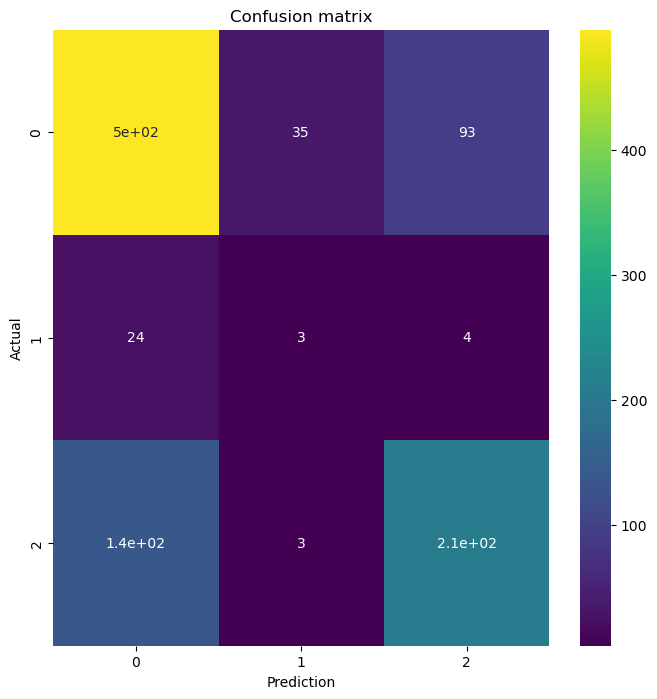

In [106]:
## Visualize a confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(conf_dt,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

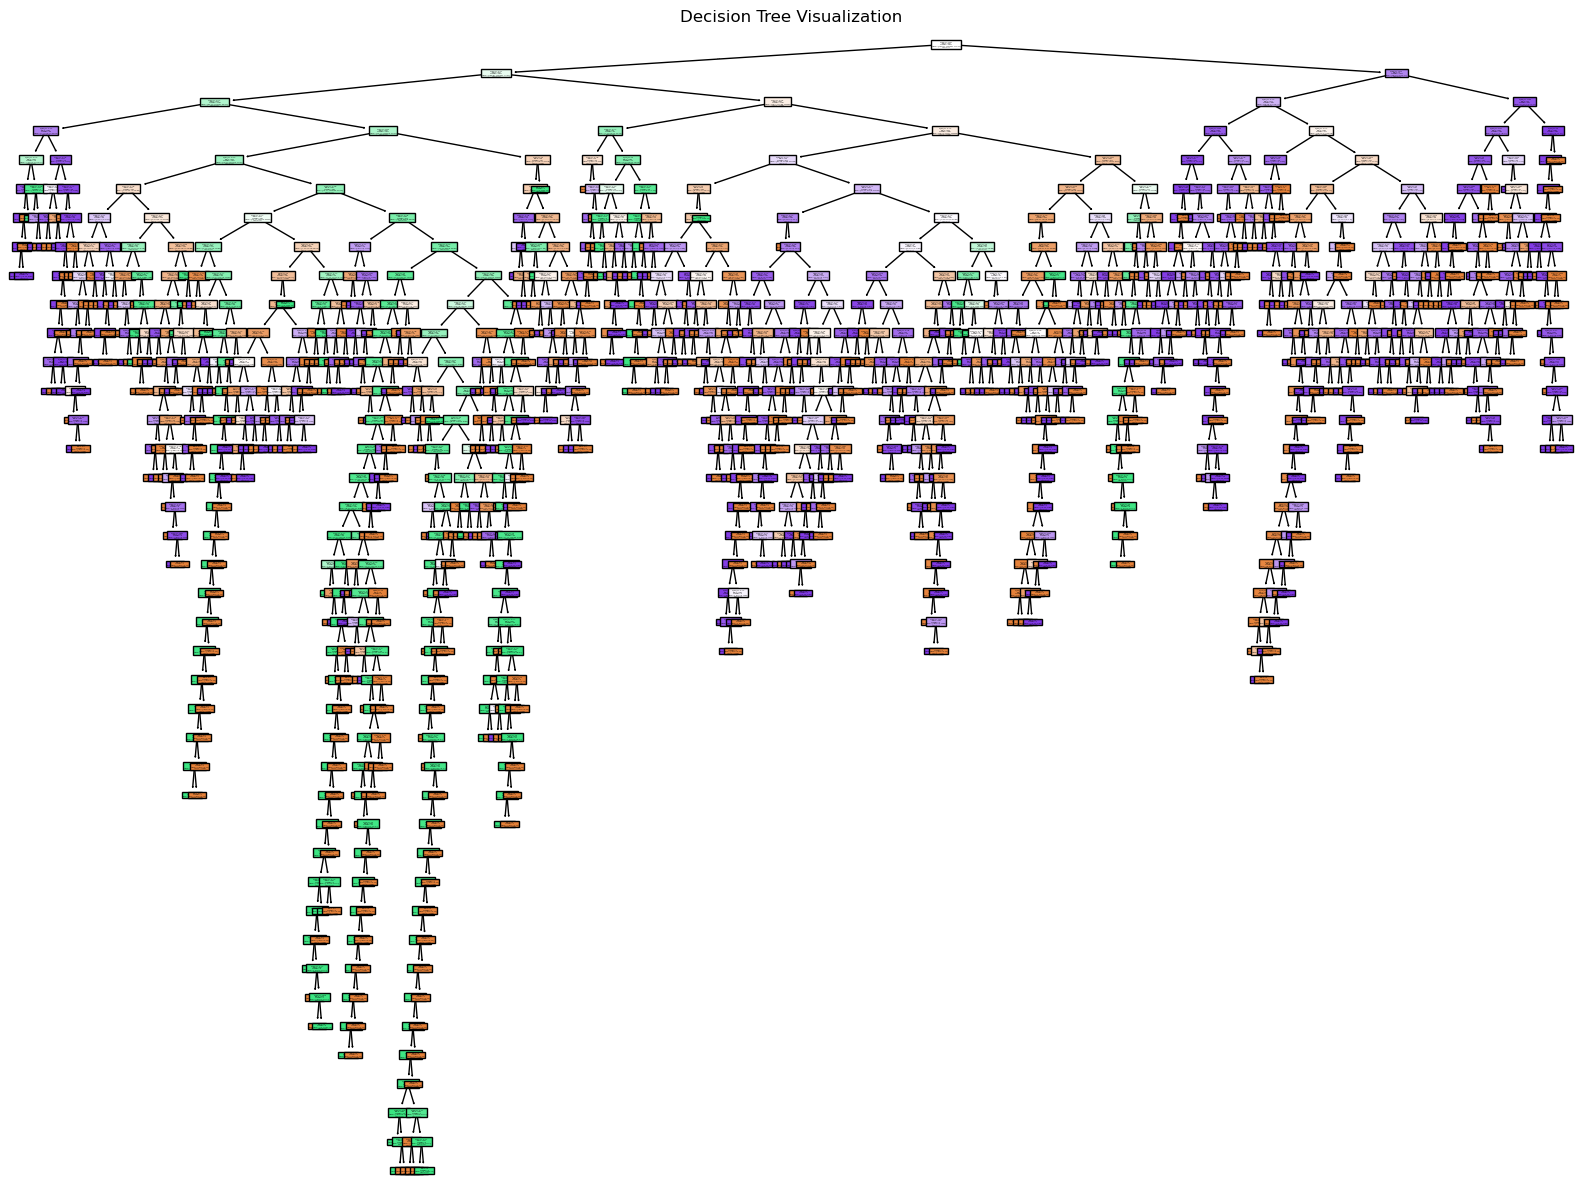

In [107]:
# extract decision tree model from pipeline
clf_dt = pipe_dt.named_steps['model']

plt.figure(figsize=(20,15))

plot_tree(
    clf_dt,
    filled=True,
    class_names=['Average','Flop','Hit']
)

plt.title("Decision Tree Visualization")

plt.show()

# Random Forest

In [108]:
preprocessor = build_preprocessor(X_train)

model_rf = RandomForestClassifier(class_weight="balanced",n_estimators=200, random_state=42)

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_rf)
])

In [109]:
# Training
pipe_rf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [110]:
# prediction

y_pred_rf = pipe_rf.predict(X_test)
df_pred_rf = pd.DataFrame({"Actual":y_test, "Prediction":y_pred_rf})
df_pred_rf.head(20)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Average
5031,Average,Average
4968,Flop,Average
4759,Hit,Average
158,Hit,Hit
713,Average,Average
4700,Average,Average
1190,Average,Hit


In [111]:
### model evaluation
accuracy_rf = accuracy_score(y_test,y_pred_rf)
conf_rf = confusion_matrix(y_test,y_pred_rf)
report_rf= classification_report(y_test,y_pred_rf)


print(f"Model Accuracy for Random Forest :{accuracy_rf*100:.2f}%")
print ("\n Classification Report for Random Forest: \n",report_rf)
print ("\n Confusion matrix for Random Forest:\n",conf_rf)

Model Accuracy for Random Forest :77.10%

 Classification Report for Random Forest: 
               precision    recall  f1-score   support

     Average       0.75      0.96      0.84       624
        Flop       0.00      0.00      0.00        31
         Hit       0.88      0.50      0.63       345

    accuracy                           0.77      1000
   macro avg       0.54      0.49      0.49      1000
weighted avg       0.77      0.77      0.74      1000


 Confusion matrix for Random Forest:
 [[600   0  24]
 [ 31   0   0]
 [174   0 171]]


C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


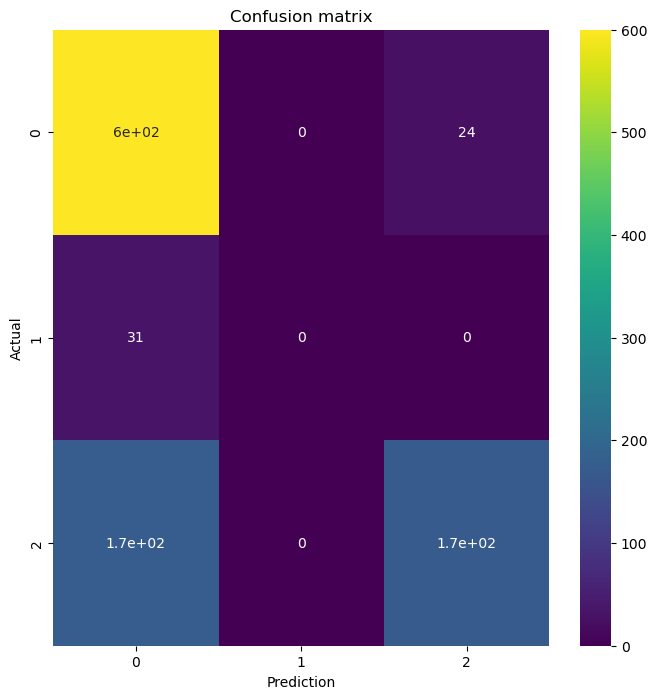

In [112]:
## Visualize a confusion matrix of random Forest
plt.figure(figsize=(8,8))
sns.heatmap(conf_rf,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

# Comparison

In [113]:
# putting models in dictionary
models = {
    "Logistic Regression": pipe_lr,
    "Decision Tree": pipe_dt,
    "Random Forest": pipe_rf
}


In [114]:
## Creating model Comparison Table
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results)

comparison_df

C:\Users\SRISHTI\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.668,0.740002,0.668,0.696321
1,Decision Tree,0.705,0.708628,0.705,0.705535
2,Random Forest,0.771,0.767632,0.771,0.742503


In [115]:
## Finding best model
comparison_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.771,0.767632,0.771,0.742503
1,Decision Tree,0.705,0.708628,0.705,0.705535
0,Logistic Regression,0.668,0.740002,0.668,0.696321


<Axes: xlabel='Model'>

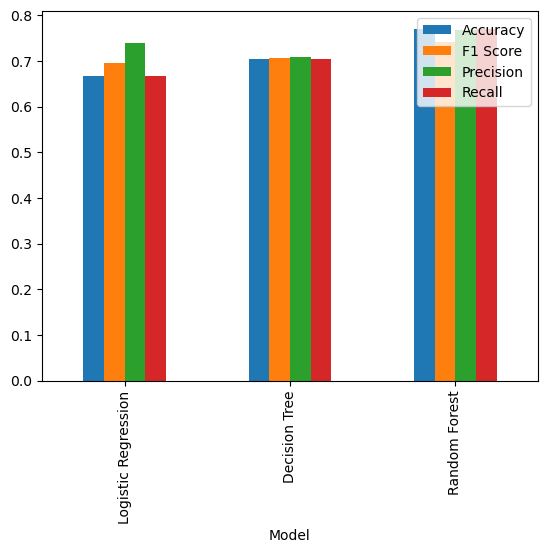

In [116]:
# Visualizing the comparison
comparison_df.set_index("Model")[["Accuracy","F1 Score","Precision","Recall"]].plot(kind="bar")

In [117]:
best_model = pipe_rf
import joblib

joblib.dump(pipe_rf, "best_movie_model.pkl")

['best_movie_model.pkl']

In [118]:
pipe_rf.predict(X_test[:20])

array(['Average', 'Hit', 'Average', 'Average', 'Average', 'Average',
       'Hit', 'Average', 'Average', 'Hit', 'Average', 'Average', 'Hit',
       'Average', 'Average', 'Average', 'Average', 'Average', 'Average',
       'Average'], dtype=object)